In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("RIT_FINAL_CLEAN_.csv")

# Parse mixed date formats
date_cols = [
    "Learner signup date", "Opportunity End Date", "Apply Date",
    "Opportunity Start Date", "Date of Birth", "Entry Created at"
]
for c in date_cols:
    df[c] = pd.to_datetime(df[c], errors="coerce", format="mixed")


In [ ]:
 #Week 2 derived fields needed for Phase 2
df["Days to Apply"] = (df["Apply Date"] - df["Learner signup date"]).dt.days
df["Opportunity Duration"] = (
    df["Opportunity End Date"] - df["Opportunity Start Date"]
).dt.days
df["Weekend Signup Flag"] = df["Learner signup date"].dt.dayofweek >= 5
df["Signup Month"] = df["Learner signup date"].dt.to_period("M").astype(str)
df["Signup Quarter"] = df["Learner signup date"].dt.to_period("Q").astype(str)

positive = {"Started", "Team Allocated"}
negative = {"Rejected", "Dropped Out", "Withdraw"}
df["Engagement Outcome Flag"] = df["Status Description"].map(
    lambda x: "Positive" if x in positive
    else ("Negative" if x in negative else "Other")
)


In [ ]:
# PHASE 2 — EDA
print("\nCATEGORY DISTRIBUTION")
print(df["Opportunity Category"].value_counts())

print("\nSTATUS DISTRIBUTION")
print(df["Status Description"].value_counts())

print("\nCOUNTRY DISTRIBUTION — TOP 15")
print(df["Country"].value_counts().head(15))

print("\nSIGNUPS BY MONTH")
print(df.groupby("Signup Month").size())

print("\nOUTCOME SUMMARY")
print(
    df.groupby("Engagement Outcome Flag")
      .agg(
          records=("Engagement Outcome Flag", "size"),
          mean_days_to_apply=("Days to Apply", "mean"),
          median_days_to_apply=("Days to Apply", "median"),
          mean_opportunity_duration=("Opportunity Duration", "mean"),
          median_opportunity_duration=("Opportunity Duration", "median"),
          weekend_rate=("Weekend Signup Flag", "mean")
    )
)



CATEGORY DISTRIBUTION
Opportunity Category
Internship     5413
Course         2024
Event           545
Competition     425
Engagement      129
Name: count, dtype: int64

STATUS DISTRIBUTION
Status Description
Rejected          3563
Team Allocated    3271
Started            761
Dropped Out        616
Waitlisted         107
Applied            105
Withdraw            84
Rewards Award       29
Name: count, dtype: int64

COUNTRY DISTRIBUTION — TOP 15
Country
United States     3976
India             2818
Nigeria            759
Ghana              275
Pakistan           217
Bangladesh          65
Egypt               49
Ethiopia            38
Kenya               38
Rwanda              28
Nepal               21
United Kingdom      18
Turkey              17
Philippines         13
Uganda              12
Name: count, dtype: int64

SIGNUPS BY MONTH
Signup Month
2023-01     219
2023-02      88
2023-03     182
2023-04     280
2023-05     406
2023-06     753
2023-07     713
2023-08    1142
2023-09    

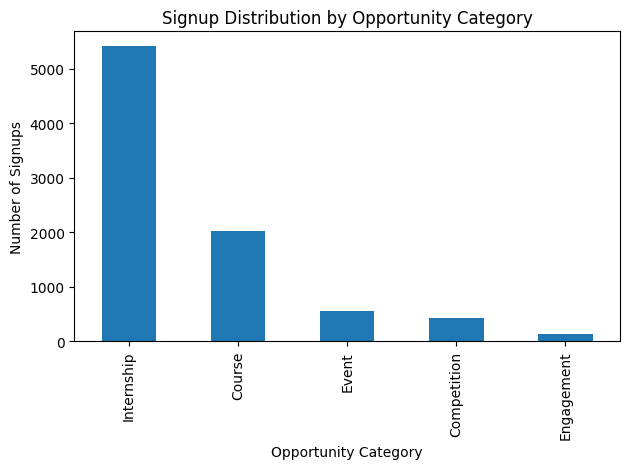

In [ ]:
# PHASE 3 — Visualizations
df["Opportunity Category"].value_counts().plot(kind="bar")
plt.title("Signup Distribution by Opportunity Category")
plt.xlabel("Opportunity Category")
plt.ylabel("Number of Signups")
plt.tight_layout()
plt.show()


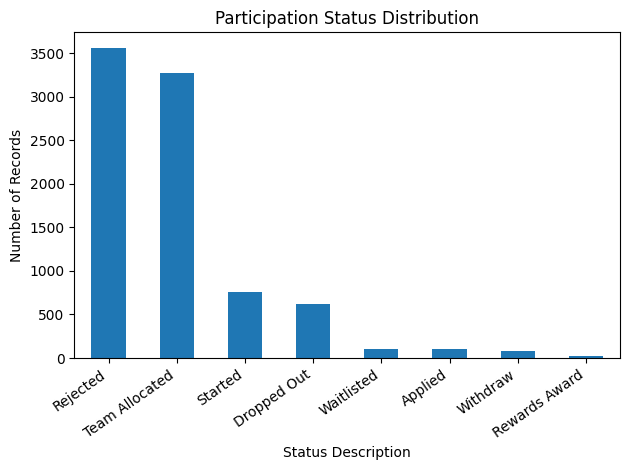

In [ ]:
# PHASE 3 — Visualizations


df["Status Description"].value_counts().plot(kind="bar")
plt.title("Participation Status Distribution")
plt.xlabel("Status Description")
plt.ylabel("Number of Records")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

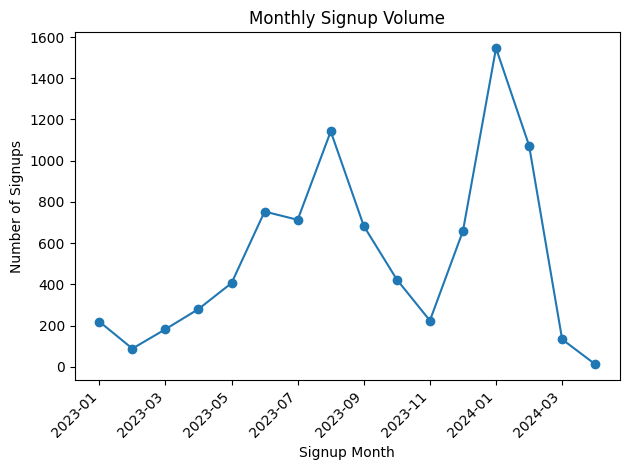

In [ ]:
# PHASE 3 — Visualizations
monthly = df.groupby("Signup Month").size()
monthly.plot(kind="line", marker="o")
plt.title("Monthly Signup Volume")
plt.xlabel("Signup Month")
plt.ylabel("Number of Signups")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


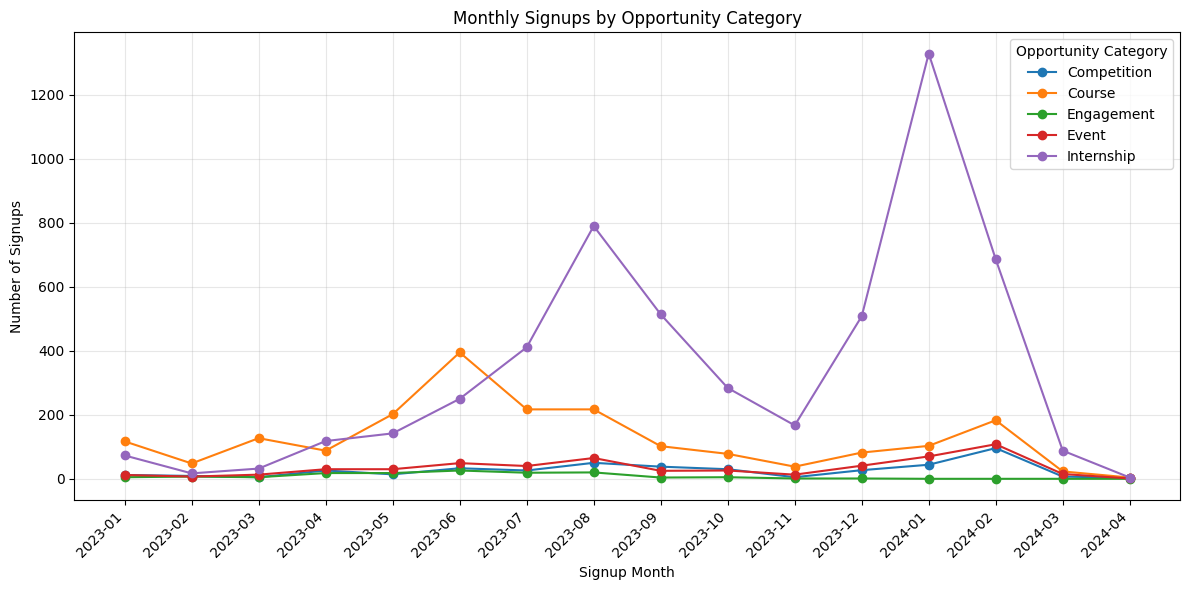

In [ ]:
# Figure 4 — Monthly Signups by Opportunity Category

import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("RIT_FINAL_CLEAN_.csv")

# Convert signup date to datetime
df["Learner signup date"] = pd.to_datetime(
    df["Learner signup date"],
    errors="coerce",
    format="mixed"
)

# Create Signup Month
df["Signup Month"] = (
    df["Learner signup date"]
    .dt.to_period("M")
    .astype(str)
)

# Count signups by month and opportunity category
monthly_category = (
    df.groupby(["Signup Month", "Opportunity Category"])
      .size()
      .reset_index(name="Signups")
)

# Convert to a format suitable for plotting
monthly_category_pivot = monthly_category.pivot(
    index="Signup Month",
    columns="Opportunity Category",
    values="Signups"
).fillna(0)

# Create the line chart
plt.figure(figsize=(12, 6))

for category in monthly_category_pivot.columns:
    plt.plot(
        monthly_category_pivot.index,
        monthly_category_pivot[category],
        marker="o",
        label=category
    )

# Titles and labels
plt.title("Monthly Signups by Opportunity Category")
plt.xlabel("Signup Month")
plt.ylabel("Number of Signups")

# Improve readability
plt.xticks(rotation=45, ha="right")
plt.legend(title="Opportunity Category")
plt.grid(alpha=0.3)

plt.tight_layout()

# Save the figure
plt.savefig(
    "04_signups_over_time_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

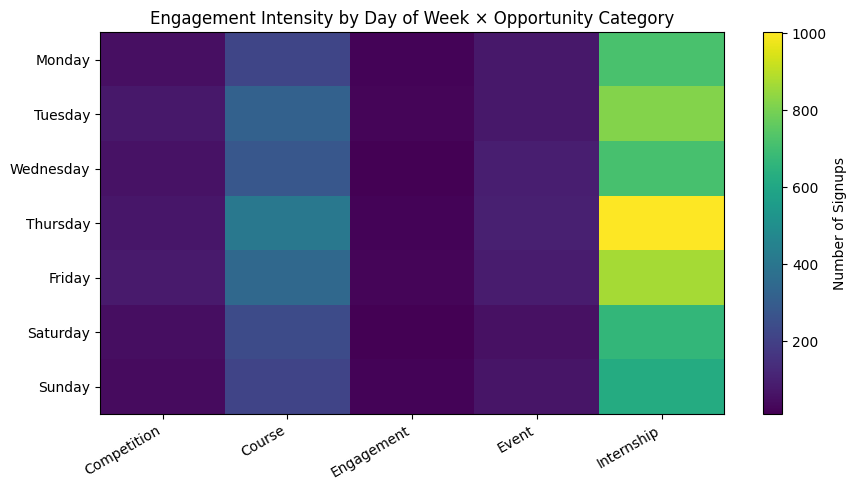

In [ ]:
# Day × category heatmap
heat = pd.crosstab(
    df["Learner signup date"].dt.day_name(),
    df["Opportunity Category"]
)
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]
heat = heat.reindex(day_order)
plt.figure(figsize=(9, 5))
plt.imshow(heat.values, aspect="auto")
plt.xticks(range(len(heat.columns)), heat.columns, rotation=30, ha="right")
plt.yticks(range(len(heat.index)), heat.index)
plt.colorbar(label="Number of Signups")
plt.title("Engagement Intensity by Day of Week × Opportunity Category")
plt.tight_layout()
plt.show()

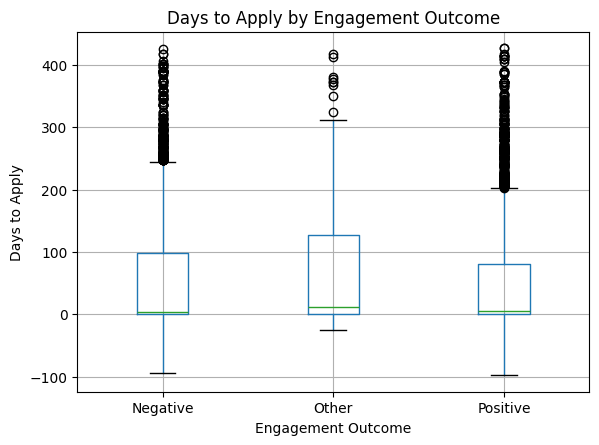

In [ ]:
# Outcome comparisons
df.boxplot(column="Days to Apply", by="Engagement Outcome Flag")
plt.suptitle("")
plt.title("Days to Apply by Engagement Outcome")
plt.xlabel("Engagement Outcome")
plt.ylabel("Days to Apply")
plt.show()


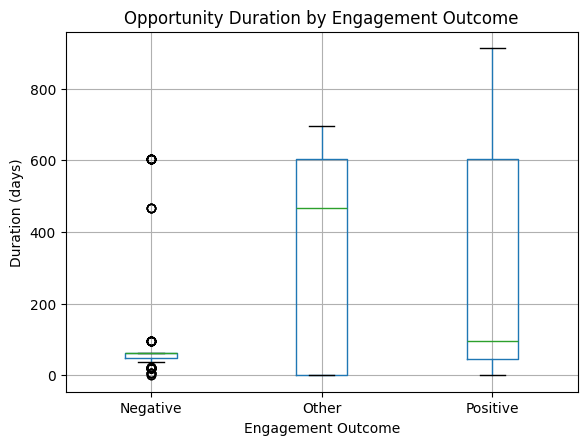

In [ ]:
df.boxplot(column="Opportunity Duration", by="Engagement Outcome Flag")
plt.suptitle("")
plt.title("Opportunity Duration by Engagement Outcome")
plt.xlabel("Engagement Outcome")
plt.ylabel("Duration (days)")
plt.show()

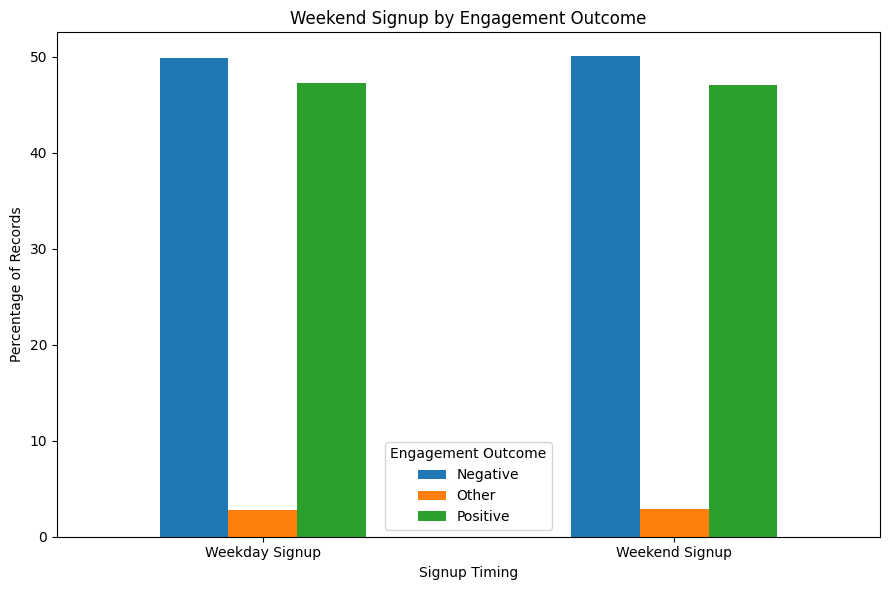

In [ ]:
# Weekend Signup × Engagement Outcome

# Re-create derived columns as df was reloaded in a previous cell
df["Weekend Signup Flag"] = df["Learner signup date"].dt.dayofweek >= 5

positive = {"Started", "Team Allocated"}
negative = {"Rejected", "Dropped Out", "Withdraw"}
df["Engagement Outcome Flag"] = df["Status Description"].map(
    lambda x: "Positive" if x in positive
    else ("Negative" if x in negative else "Other")
)

weekend_outcome = pd.crosstab(
    df["Weekend Signup Flag"],
    df["Engagement Outcome Flag"],
    normalize="index"
) * 100

# Rename x-axis labels
weekend_outcome.index = ["Weekday Signup", "Weekend Signup"]

# Plot
ax = weekend_outcome.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Weekend Signup by Engagement Outcome")
plt.xlabel("Signup Timing")
plt.ylabel("Percentage of Records")
plt.xticks(rotation=0)
plt.legend(title="Engagement Outcome")
plt.tight_layout()
plt.show()

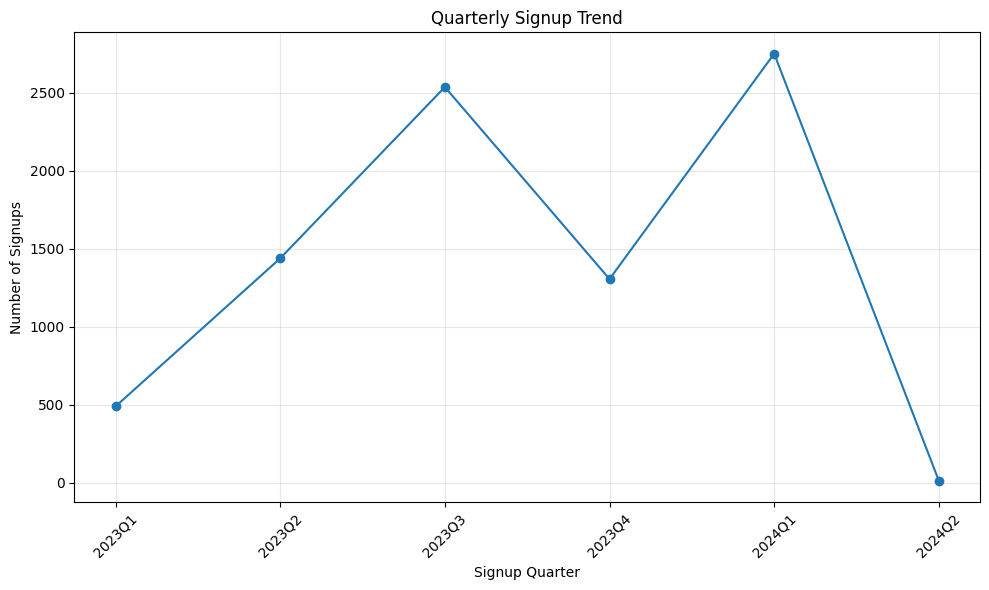

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load analysis-ready dataset
df = pd.read_csv("RIT_FINAL_CLEAN_.csv")

# Create Signup Quarter
df["Signup Quarter"] = pd.to_datetime(
    df["Learner signup date"],
    errors="coerce",
    format="mixed"
).dt.to_period("Q").astype(str)

# Count signups by quarter
quarterly_signups = (
    df.groupby("Signup Quarter")
      .size()
)

# Plot quarterly trend
plt.figure(figsize=(10, 6))

plt.plot(
    quarterly_signups.index,
    quarterly_signups.values,
    marker="o"
)

plt.title("Quarterly Signup Trend")
plt.xlabel("Signup Quarter")
plt.ylabel("Number of Signups")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

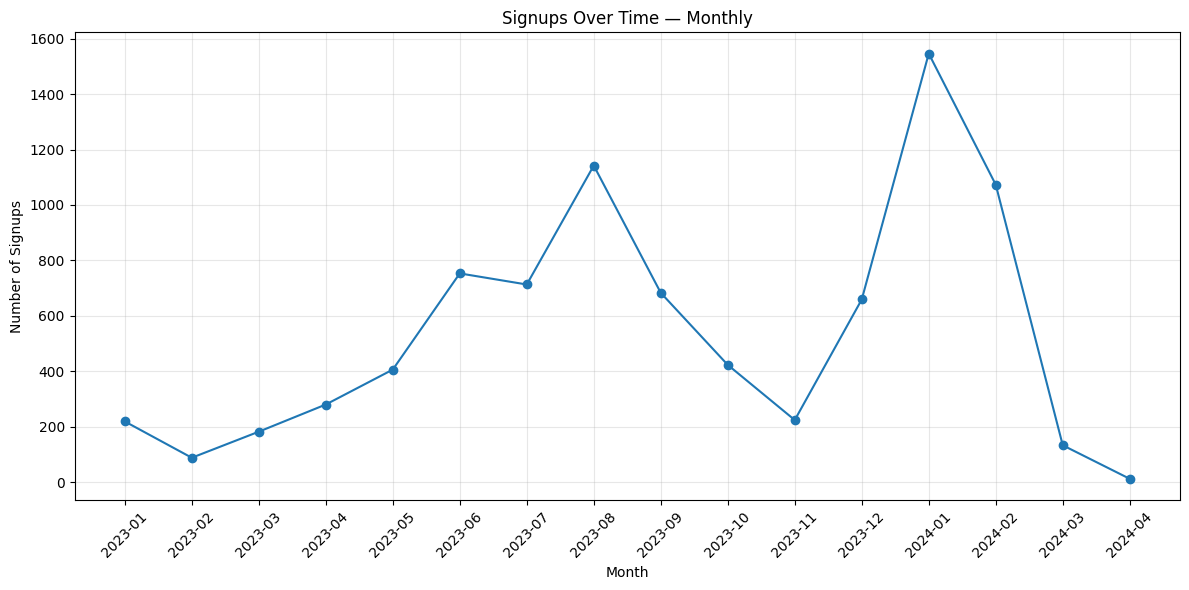

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("RIT_FINAL_CLEAN_.csv")

# Convert signup date
df["Learner signup date"] = pd.to_datetime(
    df["Learner signup date"],
    errors="coerce",
    format="mixed"
)

# Monthly signups
monthly_signups = (
    df.groupby(df["Learner signup date"].dt.to_period("M"))
      .size()
)

# Plot
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_signups.index.astype(str),
    monthly_signups.values,
    marker="o"
)

plt.title("Signups Over Time — Monthly")
plt.xlabel("Month")
plt.ylabel("Number of Signups")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

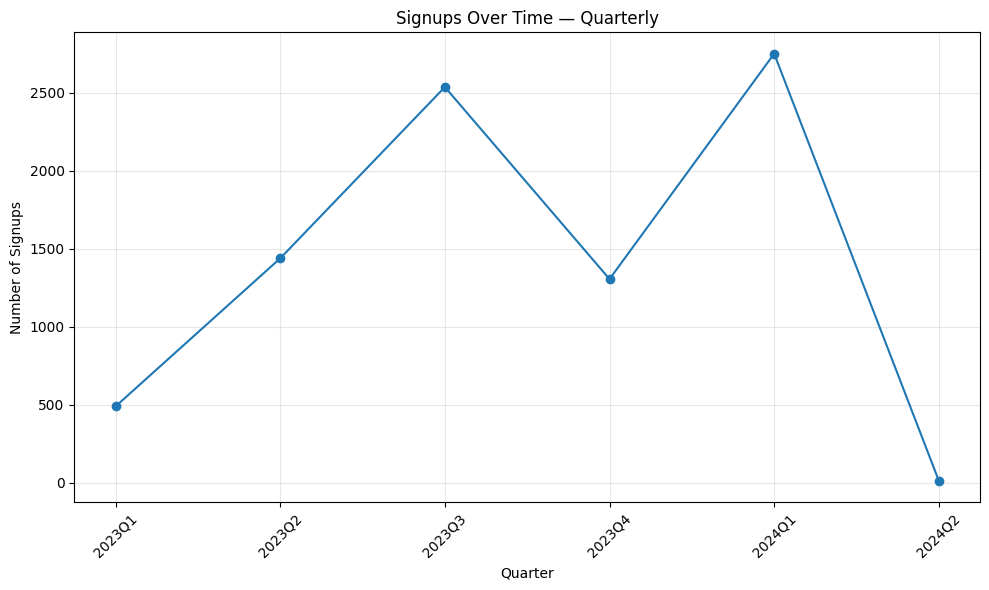

In [4]:

# Quarterly signups
quarterly_signups = (
    df.groupby(df["Learner signup date"].dt.to_period("Q"))
      .size()
)

# Plot
plt.figure(figsize=(10, 6))

plt.plot(
    quarterly_signups.index.astype(str),
    quarterly_signups.values,
    marker="o"
)

plt.title("Signups Over Time — Quarterly")
plt.xlabel("Quarter")
plt.ylabel("Number of Signups")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

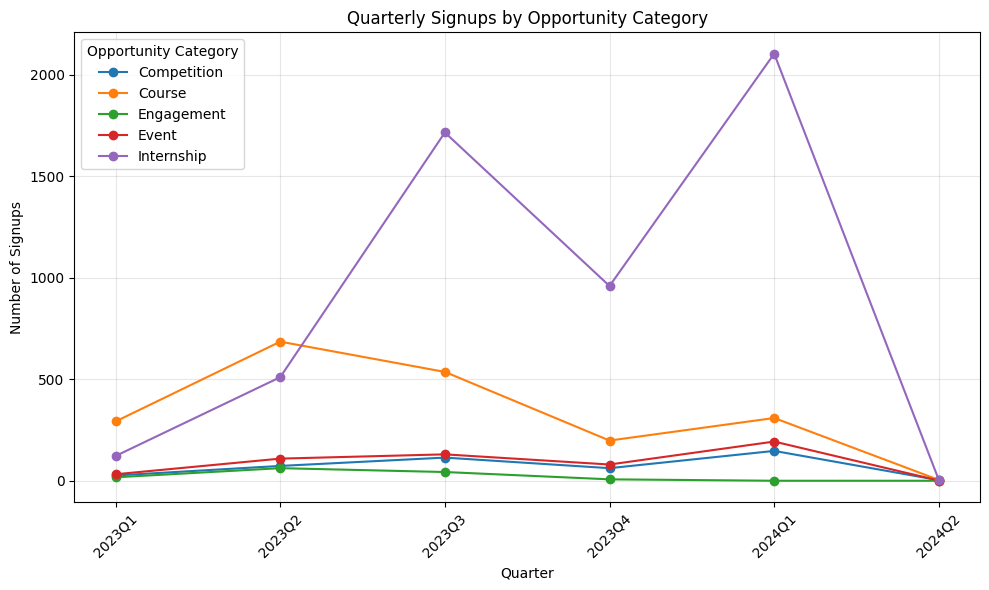

In [5]:
# Create Quarter
df["Signup Quarter"] = (
    df["Learner signup date"]
    .dt.to_period("Q")
    .astype(str)
)

# Count signups by quarter and opportunity category
quarterly_category = (
    df.groupby(["Signup Quarter", "Opportunity Category"])
      .size()
      .reset_index(name="Signups")
)

# Reshape for plotting
quarterly_category_pivot = quarterly_category.pivot(
    index="Signup Quarter",
    columns="Opportunity Category",
    values="Signups"
).fillna(0)

# Create line chart
plt.figure(figsize=(10, 6))

for category in quarterly_category_pivot.columns:
    plt.plot(
        quarterly_category_pivot.index,
        quarterly_category_pivot[category],
        marker="o",
        label=category
    )

plt.title("Quarterly Signups by Opportunity Category")
plt.xlabel("Quarter")
plt.ylabel("Number of Signups")
plt.xticks(rotation=45)
plt.legend(title="Opportunity Category")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()